### Timing: Depending size of the image, 30 min - 3 h

The raw spot coordinates were first scaled to their real-world dimensions using a conversion factor of 0.325 μm per pixel. Subsequently, a reference image was generated for each matrix type: m/z = 798.541 for the DHB matrix. These feature images were then divided into 2048 × 2048-pixel tiles with a 10% overlap between adjacent tiles. For registration, the differential interference contrast (DIC) image and the tile images were loaded into Napari. Each tile was manually aligned to the DIC image, and the resulting affine transformation matrix for each tile was recorded and applied to transform the corresponding spot coordinates.

environment: uMAIA_env  
This notebook will first generate a tiled reference image; Next, align the images outside the notebook in the Napari GUI. Save the results and go back to the notebook to apply the transformation and transfer the ion signals into single cells.

In [58]:
import numpy as np
import pandas as pd
import scanpy as sc
from pyimzml.ImzMLParser import ImzMLParser
from sklearn.preprocessing import MinMaxScaler
import tifffile
import os

In [59]:
# This is file is used to acquire the spatial location for each sampling spot
SM_file = 'demo_data/MALDI/a3-8um-root mean square.imzML'
p = ImzMLParser(SM_file)

/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000042 found with incorrect name "max count of pixel x". Updating name to "max count of pixels x".
  warn(
/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000043 found with incorrect name "max count of pixel y". Updating name to "max count of pixels y".
  warn(
/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


In [60]:
# read into generated AnnData files form uMAIA.
adata = sc.read_h5ad("demo_data/MALDI/images.h5ad")
adata

AnnData object with n_obs × n_vars = 48132 × 1117
    var: '0'
    uns: 'img_shape'

/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


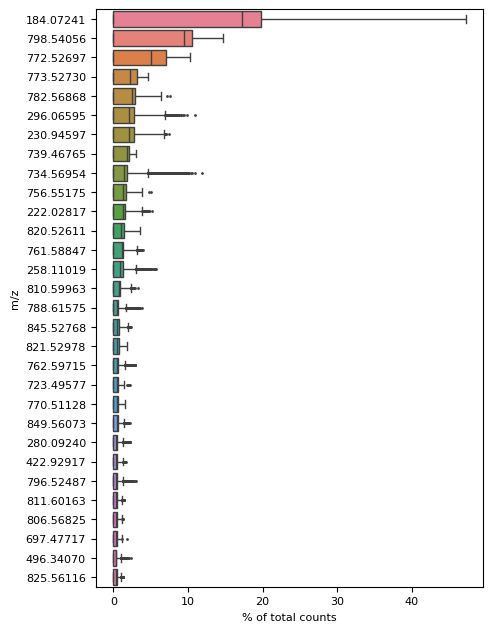

In [61]:
# Adjust the names of each mz and spatial coordinates for each spot
adata.var.columns = ['m/z']
adata.var_names = adata.var['m/z'].round(5).map('{:.5f}'.format)
adata.var_names = adata.var_names.astype(str)

X, Y = adata.uns['img_shape']
spatials = []

for x in range(X):
    for y in range(Y):
        spatials.append([y,x])
adata.obsm['spatial'] = np.array(spatials)

sc.pl.highest_expr_genes(adata)

In [62]:
# uMAIA generate AnnData also for un-scanned area, keep scanned area only

coords = np.array(p.coordinates)[:,0:2]
ref_dict = {tuple(coord): True for coord in coords}

mask = np.array([ref_dict.get(tuple(coord), False) for coord in adata.obsm['spatial']])

adata = adata[mask].copy()

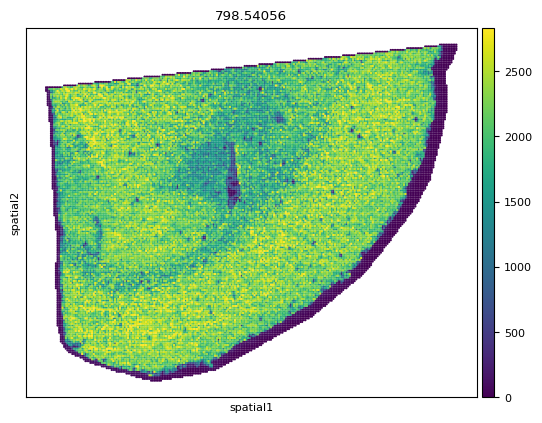

In [63]:
sc.pl.embedding(adata, basis = 'spatial', color = '798.54056', size = 10, vmax = 'p99')

In [64]:
# save the files
adata.write_h5ad("demo_data/DHB_A3_uMAIA.h5ad")

In [65]:
# Scale the spot size to real world size
scaler = MinMaxScaler((10000, 60000))

# use 798.54056 as reference m/z for image registeration
intensity = adata.to_df()['798.54056'].to_numpy().reshape(-1,1)

intensity = np.clip(intensity, 0, np.percentile(intensity, 99))

intensity = scaler.fit_transform(intensity)

adata.obs['x_raw'] = adata.obsm['spatial'][:,0] 
adata.obs['y_raw'] = adata.obsm['spatial'][:,1] 

adata.obs['x_scaled'] = (adata.obs['x_raw'])* 61.54
adata.obs['y_scaled'] = (adata.obs['y_raw'])* 61.54

adata.obs = adata.obs.reset_index(drop = True)

In [66]:
# Add a shift to move the sample to the middle of the image
adata.obs['x_scaled'] = adata.obs['x_scaled'] + 1000

In [67]:
# set a image region can cover the whole sampling area. This can be tested until satisfing
m_img = np.zeros(shape = (15000, 16780))
X,Y = m_img.shape

In [68]:
# Genertae the image of mz = 798.54056
for idx ,row in adata.obs.iterrows():
    x = row['x_scaled']
    y = row['y_scaled']
    
    x1 = int(min(Y, x))
    x2 = int(min(Y, x + 20))
    y1 = int(min(X, y))
    y2 = int(min(X, y + 20))
    
    if not x1 == x2 or y1 == y2:
        m_img[y1:y2, x1:x2] = intensity[int(idx)]

m_img = m_img.astype(np.uint16)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x7cb595c99a90>)

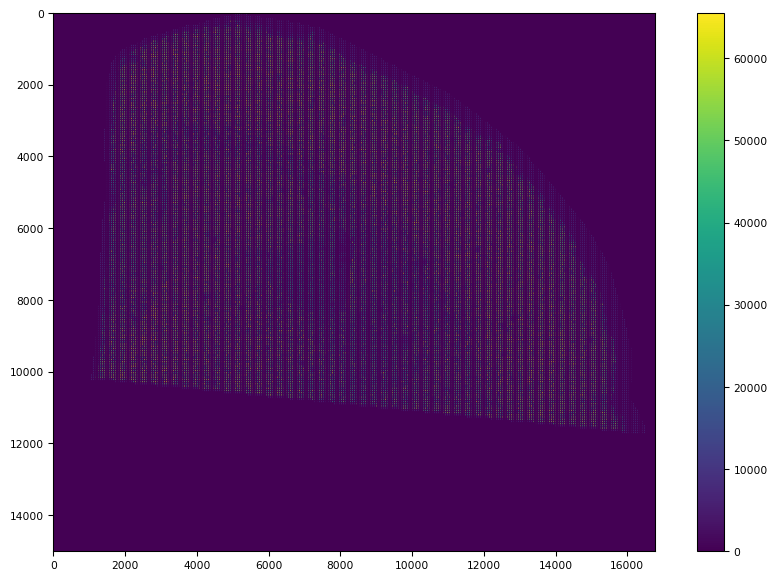

In [25]:
tifffile.imshow(m_img)

In [69]:
# Split image into tiles and save tiles for manual registration, create the tiles
tiles_path = "demo_data/MALDI/tiles"
os.makedirs(tiles_path, exist_ok=True)

tiles = []
x_pos = []
y_pos = []

m = 0

for x_step in range(int(np.ceil(X/1843))):
    for y_step in range(int(np.ceil(Y/1843))):

        x_start = x_step * 1843
        y_start = y_step * 1843
        
        x_end = min(x_start + 2048, X)
        y_end = min(y_start + 2048, Y)

        tmp_img = m_img[x_start: x_end,y_start: y_end]

        if np.sum(tmp_img) > 0:
            tifffile.imwrite(f"{tiles_path}/{m}.tif", tmp_img)

            tiles.append(m)
            x_pos.append(x_start)
            y_pos.append(y_start)

            m += 1

In [70]:
GLOBAL_GRID = pd.DataFrame({
    'tile': tiles,
    'x_pos': x_pos,
    'y_pos': y_pos
})

In [71]:
GLOBAL_GRID.to_csv(f"{tiles_path}/Grid.csv")

## Next, go to Napari, manually registered every  tiles. Store the affines transformation matrix for each tiles.

1. Open a terminal, and run the following command (or start the Napari app):
 ```bash
conda activate uMAIA_env
napari
```
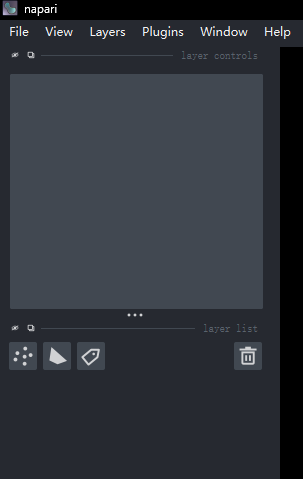  

2. Drag the DIC image into the Napari. (DIC image can be found at Result/Registration/Stitched/DIC_DIC.tif)  
   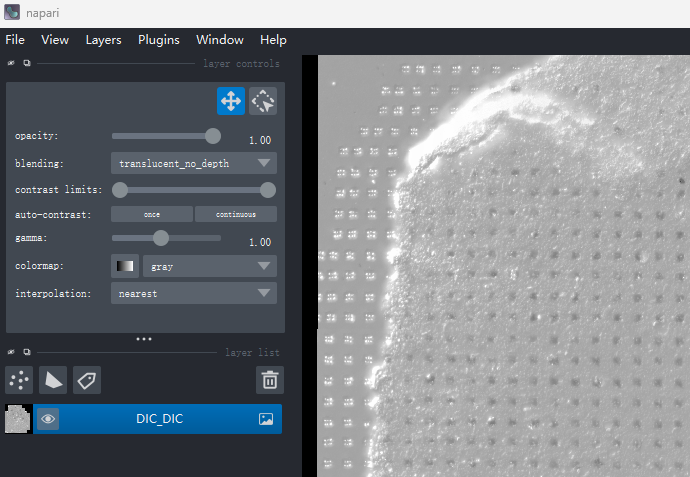

3. Drag first tile into the napari. Change the opacity to 0.60, colormap to viridis for better visualization. Activate the Transform button to start transform the tile:  
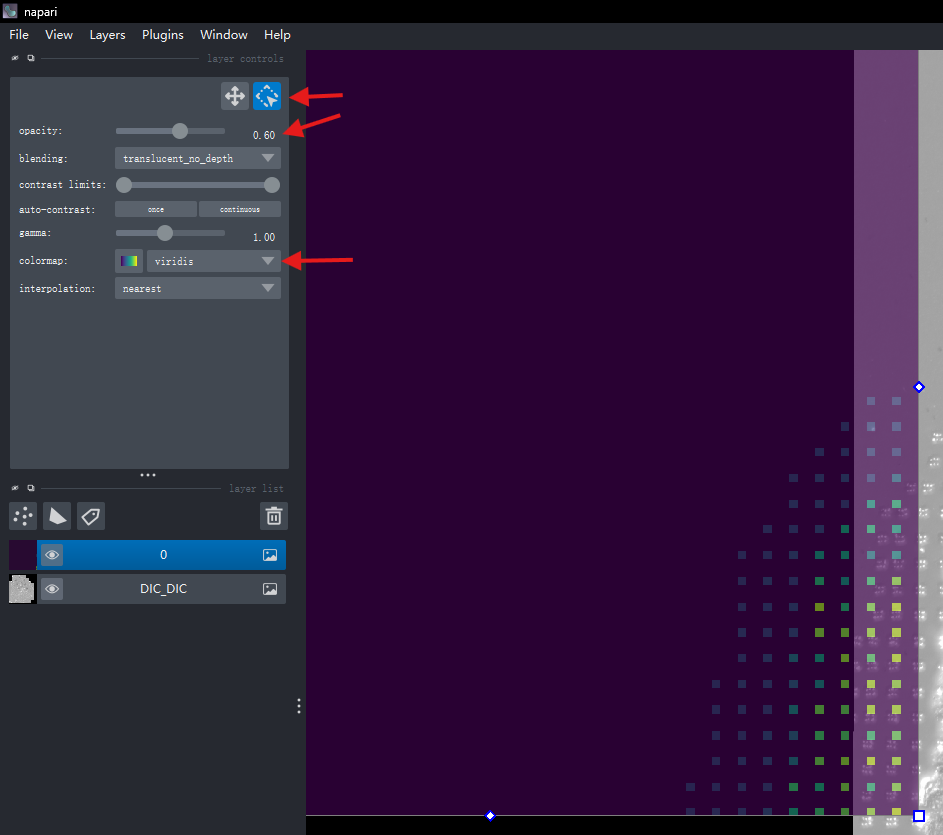  

4. Move/scale/rotate the tile to register:

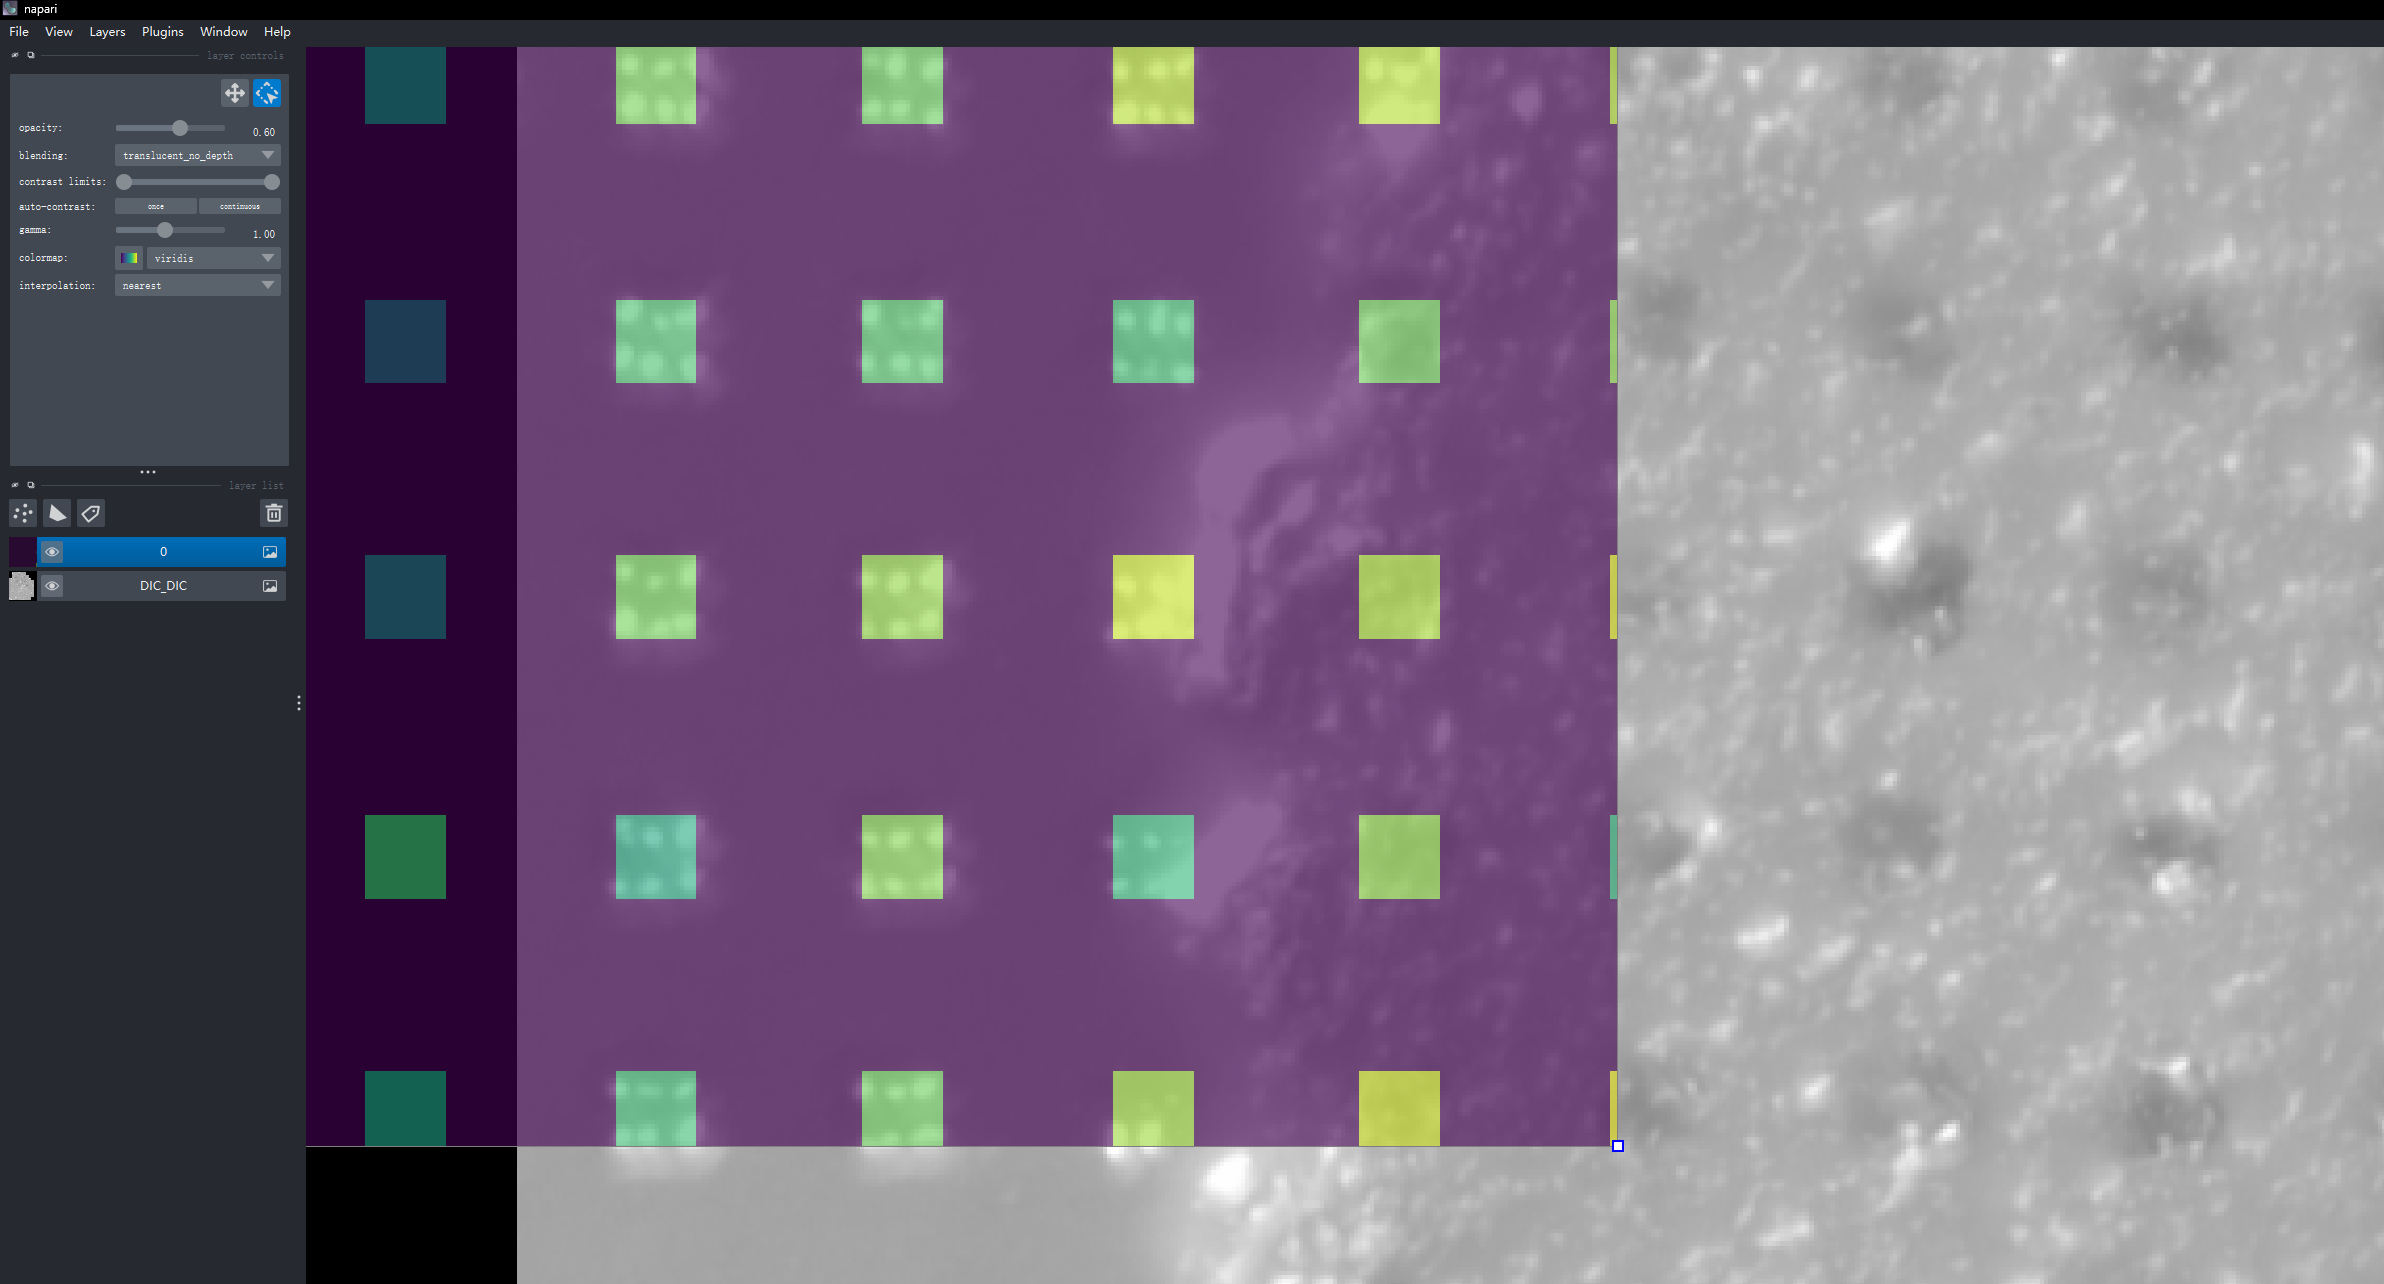

5. After registeration, right click the tile and copy the **affine** transformation.  
 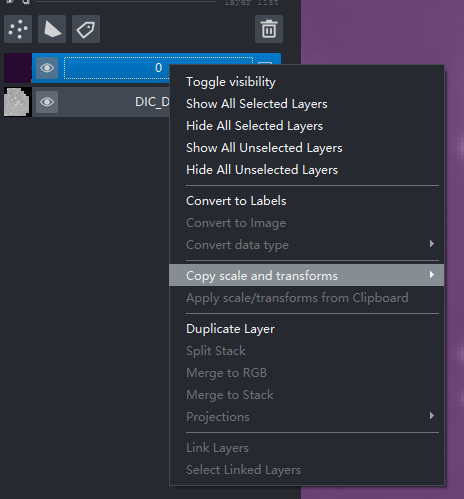

6. paste the affine transformation into a excel file. Repeat until all tiles were aligned.  
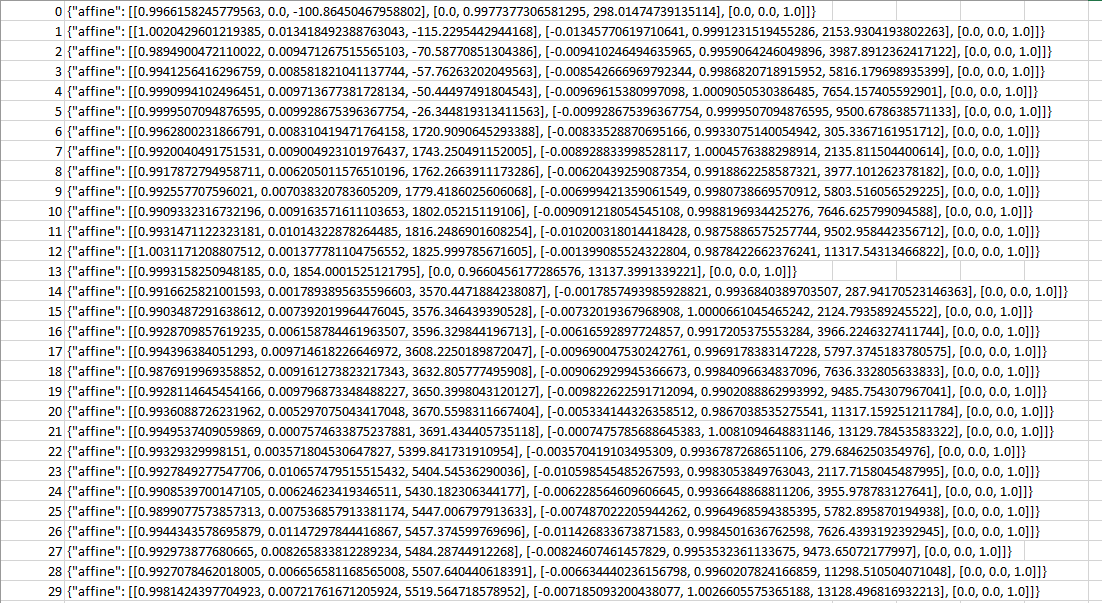

## Now, go back to this notebook

In [72]:
# read into the affine matrix for each tile
transform_df = pd.read_excel("demo_data/MALDI/transformation_matrix.xlsx", header = None)
transform_df

,0,1
0,0,"{""affine"": [[0.9966158245779563, 0.0, -100.864..."
1,1,"{""affine"": [[1.0020429601219385, 0.01341849238..."
2,2,"{""affine"": [[0.9894900472110022, 0.00947126751..."
3,3,"{""affine"": [[0.9941256416296759, 0.00858182104..."
4,4,"{""affine"": [[0.9990994102496451, 0.00971367738..."
5,5,"{""affine"": [[0.9999507094876595, 0.00992867539..."
6,6,"{""affine"": [[0.9962800231866791, 0.00831041947..."
7,7,"{""affine"": [[0.9920040491751531, 0.00900492310..."
8,8,"{""affine"": [[0.9917872794958711, 0.00620501157..."
9,9,"{""affine"": [[0.992557707596021, 0.007038320783..."


In [73]:
# Apply the transformation to the coordinates
import ast

adata.obs['x_scaled_aligned'] = -1.
adata.obs['y_scaled_aligned'] = -1.

for m, row in GLOBAL_GRID.iterrows():

    mask = (adata.obs['x_scaled'] >= row['y_pos'])&(adata.obs['x_scaled'] < row['y_pos'] + 2048)&(adata.obs['y_scaled'] >= row['x_pos'])&(adata.obs['y_scaled'] < row['x_pos'] + 2048)
    
    x_img = adata.obs['x_scaled'][mask].values
    y_img = adata.obs['y_scaled'][mask].values


    x_img = x_img - row['y_pos']
    y_img = y_img - row['x_pos']

    points_h = np.stack([y_img,x_img, np.ones_like(x_img)], axis=1)  # shape (N, 3)
    
    H = ast.literal_eval(transform_df.loc[m, 1][11:-1])
    
    transformed_h = (H @ points_h.T).T  # shape (N, 3)
    
    x_img_aligned = transformed_h[:, 0] / transformed_h[:, 2]
    y_img_aligned = transformed_h[:, 1] / transformed_h[:, 2]

    adata.obs.loc[mask, 'x_scaled_aligned'] = y_img_aligned
    adata.obs.loc[mask, 'y_scaled_aligned'] = x_img_aligned

adata.obsm['spatial_aligned'] = adata.obs[['x_scaled_aligned', 'y_scaled_aligned']].to_numpy()
adata = adata[(adata.obs['x_scaled_aligned'] >= 0)&(adata.obs['y_scaled_aligned'] >= 0)].copy()

/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [74]:
# save the results.
adata.write_h5ad("demo_data/DHB_A3_uMAIA_aligned.h5ad")